# A gage R&R study

A gage R&R study answers one question: is your measurement system good enough
to trust the numbers it produces? Before you judge a process by its data, you
have to know how much of the variation you see is the process and how much is
the gage. This notebook walks one crossed study end to end, with the printed
report and the chart.

<div class="nb-buttons"><a class="nb-btn" target="_blank" href="https://colab.research.google.com/github/cjbrant/mfgQC/blob/main/docs/guide/gage-rr.ipynb">Run in Colab</a><a class="nb-btn" target="_blank" href="https://github.com/cjbrant/mfgQC/blob/main/docs/guide/gage-rr.ipynb">View on GitHub</a><a class="nb-btn" target="_blank" href="https://raw.githubusercontent.com/cjbrant/mfgQC/main/docs/guide/gage-rr.ipynb" download>Download notebook</a></div>

Install it first (skip this if mfgQC is already in your environment):

In [ ]:
!pip install mfgqc

## 1. Lay out the data tidy

A crossed study has every operator measure every part, several times. mfgQC
wants that as a tidy frame: one row per measurement, with columns naming the
part, the operator, and the trial (replicate). Here we build a worked
dataset: 10 parts with real part-to-part spread, three operators each carrying
a small bias, and 0.25 of repeatability noise on every reading.

In [2]:
import numpy as np, pandas as pd, mfgqc

rng = np.random.default_rng(33)
parts_true = rng.normal(10.0, 2.0, size=10)     # 10 parts, real part-to-part spread
op_bias = {"A": 0.0, "B": 0.15, "C": -0.10}     # small operator-to-operator bias

rows = []
for p_id, p_true in enumerate(parts_true, start=1):
    for op, bias in op_bias.items():
        for trial in (1, 2, 3):
            val = p_true + bias + rng.normal(0, 0.25)   # repeatability noise
            rows.append({"part": p_id, "operator": op,
                         "trial": trial, "thickness": round(val, 3)})

df = pd.DataFrame(rows)
print(df.head(8).to_string(index=False))

 part operator  trial  thickness
    1        A      1     10.528
    1        A      2     10.626
    1        A      3     11.051
    1        B      1     10.583
    1        B      2     11.013
    1        B      3     11.041
    1        C      1     10.409
    1        C      2     10.739


This is a 10 parts x 3 operators x 3 trials study, 90 rows. The design must be
balanced: every part x operator cell has the same number of trials, and you
need at least 2 trials per cell (that is what repeatability is measured from).
mfgQC raises a clear `ValueError` if the design is unbalanced or has fewer than
2 trials per cell.

Pick parts that cover the normal spread of production, not 10 parts off one
good run. If the parts barely vary, part-to-part variation (PV) shrinks and the
gage looks worse than it is. Every %study-variation number is relative to total
spread.

## 2. Load and assign roles

mfgQC analyses consume a `QCData`. You build one by loading the frame and
naming the measure, then binding roles. A role maps a semantic name to one of
your columns. Gage R&R requires exactly three roles: `part` (the part or
specimen identifier), `operator` (the appraiser), and `replicate` (the trial or
repeat number).

In [3]:
qc = (mfgqc.load(df, measure="thickness")
           .roles(part="part", operator="operator", replicate="trial"))
qc

QCData(measure='thickness', n=90, roles={part, operator, replicate}, spec(none), history=2 steps)

The role keys are fixed (`part`, `operator`, `replicate`); the values are
whatever your columns are named, here `replicate="trial"`. Roles are metadata,
set fluently and immutably, so each call returns a new `QCData`.

### What happens if a role is missing

`gage_rr()` checks its prerequisites before computing anything. Leave one out
and you get a catchable, machine-readable error, not a stack trace deep in the
math.

In [4]:
from mfgqc.errors import MissingPrerequisiteError

qc_missing = (mfgqc.load(df, measure="thickness")
                   .roles(part="part", operator="operator"))   # no replicate

try:
    qc_missing.gage_rr()
except MissingPrerequisiteError as e:
    print(e)
    print("analysis =", e.analysis)
    print("missing  =", e.missing)

gage R&R requires roles {'part', 'replicate', 'operator'}; 'replicate' not defined in this QCData (defined roles: ['operator', 'part']). Set them with .roles(...).
analysis = gage R&R
missing  = ('role:replicate',)


The message names the missing role and what you do have. `e.missing` carries
the machine token (`role:replicate`) so a frontend can prompt for exactly that
input. The set in the message is unordered (Python set repr), so it may print
in any order.

## 3. (Optional) attach a tolerance for %tolerance

If you want %tolerance (the gage error judged against the engineering spec
rather than the process spread) attach a two-sided spec. Without both a lower
and upper limit, mfgQC computes everything except %tolerance and reports
`pct_tol` as absent.

In [5]:
qc = qc.spec(lower=4.0, upper=16.0)

%tolerance is 6 x GRR as a percentage of the tolerance band (upper - lower).
With only one limit (or no spec), the band is undefined, so mfgQC omits
%tolerance instead of guessing. %study variation is always reported; it needs
no spec.

## 4. Run the study

In [6]:
res = qc.gage_rr()       # method="anova" by default
print(res.report())

Gage R&R (method=anova)
Design: 10 parts x 3 operators x 3 trials
Verdict: marginal (conditionally acceptable)   ndc = 10

component          std dev   lower 90%   upper 90%  %study var   %contrib
Repeatability(EV)   0.22673       0.201       0.261      12.21%      1.49%
Reproducib.(AV)    0.11451       0.057       0.536       6.17%      0.38%
GRR                  0.254       0.223       0.582      13.68%      1.87%
Part(PV)            1.8399       1.341       3.029      99.06%     98.13%
Total(TV)           1.8573                             100.00%    100.00%

interaction pooled into error (not significant)

%tolerance (GRR) = 12.70%

Assumption checks:
  [PASS] normality (Anderson-Darling): AD=0.302, p=0.571; skew 0.135; n=90
  [PASS] homogeneity_of_variance (Levene): variance ratio 1.05, p=0.988; n=90
  [PASS] ndc_adequacy (ndc (AIAG ndc>=5)): ndc 10; n=90


The default `method="anova"` includes the part x operator interaction and
reports 90% (not 95%) component confidence limits, the AIAG convention. The
Average-and-Range method is available with `qc.gage_rr(method="xbar_r")`; it
reports point estimates only (no CIs) and no interaction term.

## 5. Read the output

Each row is a variation component, reported as a standard deviation, then as a
percentage two different ways.

| Component | What it is | Fix when it dominates |
| --- | --- | --- |
| **EV** (Repeatability) | same operator, same part, repeated, the gage's own noise | gage, fixture, resolution |
| **AV** (Reproducibility) | operator-to-operator differences | training, SOP, technique |
| **GRR** | total measurement error, sqrt(EV^2 + AV^2) (+ interaction) | the larger of EV / AV |
| **PV** | part-to-part, the real product variation | (this is what you want to see) |
| **TV** | total observed variation, sqrt(GRR^2 + PV^2) | n/a |

Two percentage columns answer two different questions:

- **%study variation**: each component as a percent of total study spread (TV).
  Use this to judge the gage against the process: can it resolve the parts you
  actually make? These are std-dev ratios, so they do not sum to 100%.
- **%contribution**: each component's variance as a percent of total variance.
  This is the column that adds to 100%.
- **%tolerance** (printed separately): GRR against the spec band. Use this when
  the measurement only has to be good enough to sort to spec (pass/fail), not to
  resolve process spread.

The matching scalars are on `summary()` and `to_dict()`. Read those from code,
never parse the report text.

In [7]:
s = res.summary()
{k: s[k] for k in ("pct_study_GRR", "pct_tol_GRR", "ndc", "verdict")}

{'pct_study_GRR': 13.675457499518055,
 'pct_tol_GRR': 12.700006346694437,
 'ndc': 10,
 'verdict': 'marginal (conditionally acceptable)'}

**ndc** (number of distinct categories) = `int(1.41 x PV / GRR)`, truncated. It
is how many non-overlapping groups of parts the gage can reliably tell apart.

**Pooling.** With `method="anova"`, mfgQC tests the part x operator
interaction. Following AIAG, if it is not significant at alpha = 0.25 (p > 0.25)
it is pooled into the error term, and the report says so. If it were
significant, the line would read `retained (significant)` and the interaction
would carry its own variance. A significant interaction means some operators
measure some parts differently, worth investigating on its own. In this study
the interaction is not significant, so it is pooled.

## 6. The AIAG verdict

mfgQC turns %study-variation of GRR plus ndc into the standard AIAG call.

| %study var (GRR) | ndc | Verdict |
| --- | --- | --- |
| < 10% | >= 5 | **acceptable** |
| 10-30% | n/a | **marginal (conditionally acceptable)** |
| > 30% | n/a | **unacceptable** |
| n/a | < 2 | **unacceptable** |

To call a gage flatly acceptable, AIAG wants %GRR below 10% and ndc at least 5.
A marginal gage resolves parts well but its error sits in the 10-30% band:
usable for many applications, watch it for critical or tight-tolerance work.

ndc also drives an assumption check (`ndc_adequacy`): it passes when ndc >= 5
and, when it fails, recommends improving gage resolution. mfgQC reports the
verdict and the checks; it does not silently re-grade or re-compute.

## 7. What to do with a bad result

A bad GRR is actionable because it splits into two named causes. Read which one
dominates and fix that one:

- **EV (repeatability) dominant**: the equipment is noisy. Same operator cannot
  repeat the same part. Fixes are mechanical: a finer-resolution gage, a better
  fixture or clamp, a cleaner datum, controlling for temperature or vibration.
  Operator training will not help here.
- **AV (reproducibility) dominant**: the operators disagree. Different people
  get different numbers on the same part. Fixes are procedural: a written,
  unambiguous measurement SOP, hands-on training, removing judgment from the
  readout (digital vs analog), defining the seating of the part.
- **Both high**: start with repeatability. Until the gage can repeat itself, you
  cannot tell whether operators truly disagree or are chasing gage noise.
- **Significant interaction** (not pooled): a specific operator struggles with
  specific parts. Look for technique that depends on part geometry, then
  standardize it.

After any fix, re-run the study and compare. Every result draws its own chart:
the component breakdown and the per-operator spread side by side.

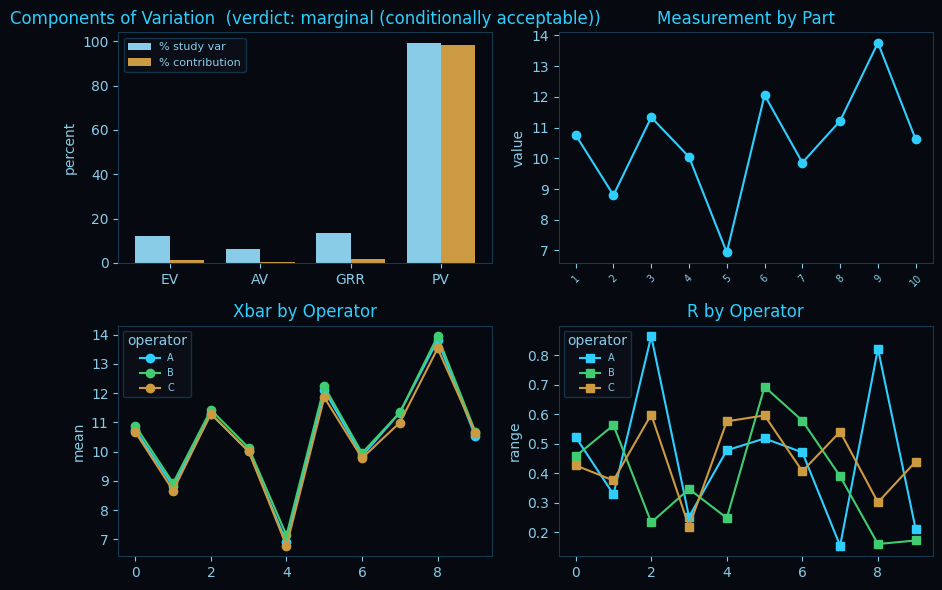

In [8]:
res.view()

Capture the result's provenance digest so the before/after comparison is
auditable. The digest pins the computation (operation, params, n affected), so
an archived result and a re-run can be checked against each other.

In [9]:
res.provenance_digest()

'0976482185fb108cc02abc18f832731c6799b42efb137c20414a04a377c31f09'

## Next

- [Gage R&R reference](/reference/gage-rr/): the ANOVA and X-bar-R formulas,
  ndc, and the confidence intervals.
- [Measurement systems analysis](/reference/msa/): where gage R&R sits in the
  wider MSA picture.